# Exploratory Data Analysis & Intro

## Goal

1. Investigate top-paying roles and skills in the data science industry.
2. Use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.

##Final Deliverables:

* Create Jupyter Notebooks (showcasing core skills in Python).
* Create a summary page (via README.md) capturing your findings.
* Share this project via GitHub & Linkedin.

In [3]:
#Libraries import code
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from datasets import load_dataset

#datasets/dataframes to be used
dataset = load_dataset('coachprerakmehta/data_jobs')
df = dataset['train'].to_pandas()

#quick data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if isinstance(skill_list, str) and pd.notna(skill_list) else skill_list)

In [5]:
#filter by US country and Data Analyst role only.
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]

In [7]:
#line to provide a variable that consider the following: Count of job postings by location inside US filtering only top 10 locations generated on a dataframe
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

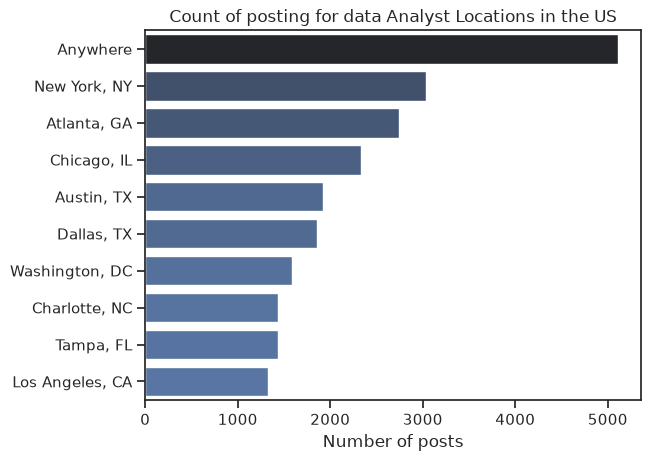

In [12]:
#Seaborn barplot with the count of job location postings. Added details such as title, and proper format to the chart using the seaborn library
#Theme set up for the chart that will be displayed below
sns.set_theme(style='ticks')
#barplot general details
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
plt.title('Count of posting for data Analyst Locations in the US')
plt.xlabel('Number of posts')
plt.ylabel('')
plt.show()

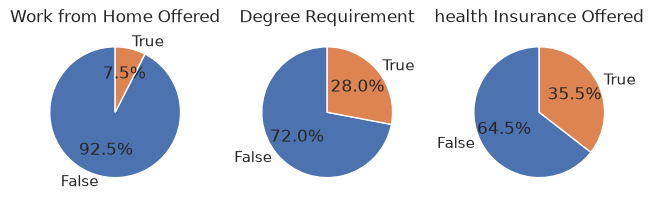

In [17]:
#pie chart on the job work from home data, job no degree required and health insurance
#trigger for multiple charts within one visualization
fig, ax= plt.subplots(1,3)
#dictionary to plot multiple charts
dict_column = {
    'job_work_from_home':'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'health Insurance Offered'
}
#loop
for i,(column,title) in enumerate(dict_column.items()):
#code for chart mapping asigning values, start angle, percentage on labels and labels asigned
    ax[i].pie(df_DA_US[column].value_counts(),startangle=90, autopct="%1.1f%%",labels=[False,True])
#this code will asign title to each chart based on the above created dictionary
    ax[i].set_title(title)
#this will make the adjustment on the title size to not overlap with other titles
fig.tight_layout()

#display charts without the textmarker above the plotted area
plt.show()

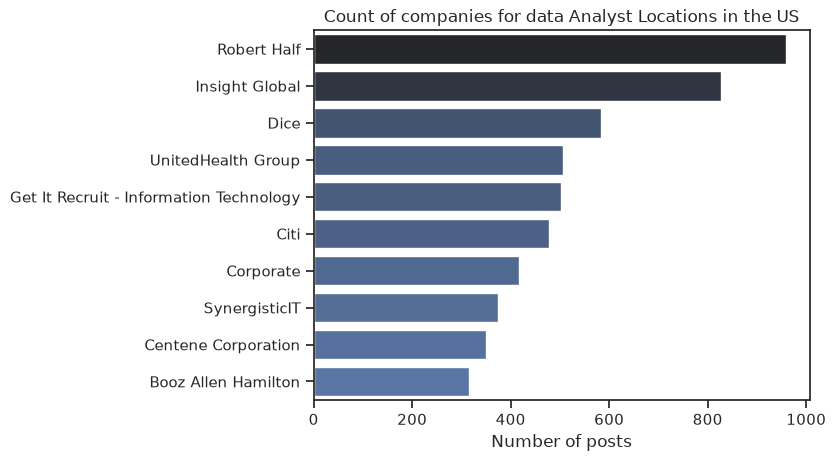

In [18]:
#code to plot job postings by company name
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
#Theme set up for the chart that will be displayed below
sns.set_theme(style='ticks')
#barplot general details
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
plt.title('Count of companies for data Analyst Locations in the US')
plt.xlabel('Number of posts')
plt.ylabel('')
plt.show()